### Code for Assignemnt and Experiment MPRAsnakeflow results of different mapping strategies

In [1]:
import pandas as pd
import gzip # zipped files
from Bio import SeqIO


writing = False

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


In [ ]:
# helpful functions
def read_zipped_fasta(fasta_file):
    """
    Read zipped fasta file with Biopython.
    """
    handle = gzip.open(fasta_file, 'rt')
    fasta_sequences = SeqIO.parse(handle,'fasta')
    return fasta_sequences


def fasta_to_dataframe(fasta_file):
    """
    Convert a fasta file to a pandas dataframe.
    """
    # case for ziped files:
    if fasta_file.endswith('.gz'):
        fasta_sequences = read_zipped_fasta(fasta_file)
    else:
        fasta_sequences = SeqIO.parse(open(fasta_file),'fasta')
    header = []
    sequence = []
    for fasta in fasta_sequences:
        header.append(fasta.id)
        sequence.append(str(fasta.seq))
    df = pd.DataFrame({'header': header, 'sequence': sequence})
    return df


def get_mean_and_median_barcode_per_oligo(df, barcode_count_column='barcode_counts'):
    """
    The dataframe contains the columns barcode_counts and sequence_name.
    It returns the median and the mean barcode per oligo.
    """
    return df[barcode_count_column].mean(), df[barcode_count_column].median()


def get_filtered_barcode_count_df(df, threshold=10, barcode_counts_column='barcode_counts'):
    """
    The dataframe contains the columns barcode_counts and sequence_name.
    It returns a filtered dataframe that only contains oligos with a barcode count higher than the threshold.
    """
    return df.loc[df[barcode_counts_column] >= threshold]


def get_number_of_assigned_oligos_filtered(df, threshold=10, barcode_counts_column='barcode_counts'):
    """
    The dataframe contains the columns barcode_counts and sequence_name.
    It returns the number of oligos that have a barcode count higher than the threshold.
    """
    return len(df.loc[df[barcode_counts_column] >= threshold])


def get_proportion_of_assigned_oligos_filtered(df, threshold=10, barcode_counts_column='barcode_counts', max_number_oligos=80141):
    """
    The dataframe contains the columns barcode_counts and sequence_name.
    It returns the proportion of oligos that have a barcode count higher than the threshold.
    """
    return round(len(df.loc[df[barcode_counts_column] >= threshold]) / max_number_oligos * 100,2)


def get_number_tested_oligos(design_df, label_name='cardiac_neuro_cava_random', col_name='header'):
    """
    The dataframe contains the columns barcode_counts and sequence_name.
    It returns the number of oligos that have a sequence name starting with 'cardiac_neuro_cava_random'.
    """
    return len(design_df.loc[design_df[col_name].str.startswith(label_name)])


def get_number_of_variants_assigned(variant_map_df, barcode_counts_df_filtered, barcode_counts_column='barcode_counts', header='sequence_name', col_ALT='ALT', col_REF='REF'):
    """
    For the filtered barcode count df, left join to the variant map (REF, ALT) and returns the number of variants with measurements in the barcode counts df
    """
    ref_merged_barcode_df = pd.merge(variant_map_df, barcode_counts_df_filtered, how='left', left_on=col_REF, right_on=header)
    ref_alt_merged_barcode_df = ref_merged_barcode_df.merge(barcode_counts_df_filtered, how='left', left_on=col_ALT, right_on=header, suffixes=('_REF', '_ALT'))

    # check which rows have are non nan in barcode_counts_REF and barcode_counts_ALT
    varaints_associated_df = ref_alt_merged_barcode_df.loc[~ref_alt_merged_barcode_df[f'{barcode_counts_column}_REF'].isna() & ~ref_alt_merged_barcode_df[f'{barcode_counts_column}_ALT'].isna()]
    return len(varaints_associated_df)


def get_number_of_tested_elements_assigned(varaint_map_df, barcode_counts_df_filtered, header='sequence_name', label_name='cardiac_neuro_cava_random', col_ALT='ALT', col_REF='REF'):
    """
    A sequence name is described as element if it is not within the variant map [ALT] column
    """
    tested_barcode_counts_df_filtered = barcode_counts_df_filtered.loc[barcode_counts_df_filtered[header].str.startswith(label_name)].copy()
    # left join of variant_map_df[ALT] to the barcode_counts_df_filtered[sequence_name]
    barcode_counts_df_variant_alt_assigned = pd.merge(tested_barcode_counts_df_filtered, varaint_map_df, how='left', left_on=header, right_on=col_ALT)
    elements_assigned = barcode_counts_df_variant_alt_assigned.loc[barcode_counts_df_variant_alt_assigned[col_REF].isna()].copy()

    # drop all columns that were added by the merge
    elements_assigned.drop(columns=[col for col in varaint_map_df.columns], inplace=True)
    return len(elements_assigned)


def get_number_of_expected_tested_elements(design_table, variant_map_df, label_name='cardiac_neuro_cava_random', col_name='header', col_ALT='ALT', col_REF='REF'):
    """
    Creates tested elements df and returns the number of elements within the barcode_counts table
    """
    design_table_variant_info = design_table.merge(variant_map_df, how='left', left_on=col_name, right_on=col_ALT)
    element_design_table = design_table_variant_info.loc[design_table_variant_info[col_REF].isna()].copy()
    # drop unnecessary columns
    element_design_table.drop(columns=[col for col in variant_map_df.columns], inplace=True)
    tested_elements = element_design_table.loc[element_design_table[col_name].str.startswith(label_name)].copy()
    return len(tested_elements)


def get_number_of_tested_variants(variant_map_df, label_name='cardiac_neuro_cava_random', col_ALT='ALT'):
    return variant_map_df.loc[variant_map_df[col_ALT].str.startswith(label_name)][col_ALT].nunique()


def get_number_of_variants(variant_map_df, col_ALT='ALT'):
    return variant_map_df[col_ALT].nunique()

### Assignment
1. Read variant map and design file (maybe generate the variant map from the metadata file if you now have one yet)
2. Generate count tables
3. Count the oligos, elements and variants assigned
4. Plot the results

#### 1: Read variant map and metadata file (counts should have the same name as the metadata)

In [8]:
# read in the asd metadata and divide between elements and variants
metadata_path = "/data/cephfs-2/unmirrored/groups/kircher/IGVF_data_submssion_TM/ASD_nadav/design/design_ASD_inclVariants_indelFix_headerFix_arrayFix.hg38.tsv.gz"
metadata_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/NGN2_element_metadata_with_bcalm_2025_04_normalized_counts_bbmap_vs_neuro_ctrl.tsv.gz"
metadata_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_pvalue_log2_zscore_scrambled_log2_zscore_neuro_ctrl.tsv.gz"

metadata_df = pd.read_csv(metadata_path, sep="\t", low_memory=False)

In [9]:
metadata_df.category.value_counts()

category
variant      67391
element      12025
scrambled      599
synthetic      200
Name: count, dtype: int64

In [ ]:
# metadata_df['matchable_name'] = metadata_df["name"].apply(lambda name: name.replace(" ", "_"))

In [7]:
metadata_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,matchable_name
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,['ref'],NaN,1.000000,-0.020025,True,GC_Mohlke,-0.020025,1.607299,0.020912,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,['ref'],NaN,1.000000,0.023178,True,GC_Mohlke,0.023178,2.311854,0.743514,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"['ref', 'ref']",NaN,1.000000,0.030124,True,GC_Mohlke,0.030124,2.425133,0.859695,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,['alt'],NaN,1.000000,0.008197,True,GC_Mohlke,0.008197,2.067540,0.492942,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,['ref'],NaN,1.000000,-0.004511,True,GC_Mohlke,-0.004511,1.860305,0.280399,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,NaN,NaN,1.000000,0.046735,True,GC_Glut_Chengyu,0.046735,2.696008,1.137508,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,NaN,NaN,1.000000,0.084739,True,GC_Glut_Chengyu,0.084739,3.315786,1.773161,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,NaN,NaN,0.338260,0.097477,True,GC_Glut_Chengyu,0.097477,3.523500,1.986196,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,NaN,NaN,0.000374,0.125486,True,GC_Glut_Chengyu,0.125486,3.980281,2.454677,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...


##### Optional: prepare the variant map from the metadata file (might need to change the way ref and alt are defined for your dataset)´


In [ ]:
# output_path_variant_map = "ASD_variant_map.tsv.gz"

# # 1) Group by genomic coordinates, aggregate names and sequences
# grouped = (
#     metadata_df
#     .groupby([col_chr, col_start, col_end, col_strand])
#     .agg({"matchable_name": list, col_sequence: list})
#     .reset_index()
# )

# # 2) Filter only groups with more than one sequence
# grouped['n_sequences'] = grouped[col_sequence].apply(len)
# grouped = grouped[grouped['n_sequences'] > 1].copy()

# # 3) Choose the first entry as REF (this is a dataset specific property: NOTE: not general!)
# grouped['REF'] = grouped["matchable_name"].str[0]
# grouped['REF_sequence'] = grouped[col_sequence].str[0]
# grouped['ALT_names'] = grouped["matchable_name"].str[1:]
# grouped['ALT_sequences'] = grouped[col_sequence].str[1:]

# # 4) Explode to one line per ALT
# exploded = grouped.explode(['ALT_names', 'ALT_sequences']).reset_index(drop=True)

# # 5) Finalize variant table
# variant_map_df = exploded[[col_chr, col_start, col_end, col_strand,
#                            'REF', 'REF_sequence',
#                            'ALT_names', 'ALT_sequences']]

# variant_map_df = variant_map_df.rename(columns={
#     'ALT_names': 'ALT',
#     'ALT_sequences': 'ALT_sequence'
# })

# # print(variant_map_df)
# if writing:
#     variant_map_df.to_csv(output_path_variant_map, sep="\t", index=False)

In [10]:
variant_map_path = "/home/kisa/coding/80K_MPRA/server_results/80k_counts_after_metadatafile/unique_id_renamed_variant_region_map_mprasnakeflow_input_tilde2comma.tsv.gz"
variant_map_df = pd.read_csv(variant_map_path, sep="\t")

In [11]:
variant_map_df

,ID,REF,ALT
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
...,...,...,...
47039,C_positive_heart_CAD:ALT_rs7865618_rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618
47040,C_positive_heart_CAD:ALT_rs4977757_rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757
47041,C_positive_heart_CAD:ALT_rs1537373_rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373
47042,C_positive_heart_CAD:ALT_rs10811656_rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656


#### 2: Generate count tables: (you might want to copy this into a shell script and run using slurm with the script below (depending on the size of the library you might want to change the memory and time))


Possible slurm script

In [ ]:
#!/bin/bash
#SBATCH --job-name=generate_count_tables
#SBATCH --output=generate_count_tables_%j.out
#SBATCH --error=generate_count_tables_%j.err
#SBATCH --time=01:00:00   # Set max time as needed
#SBATCH --mem=2G          # Set memory as needed
#SBATCH --cpus-per-task=1 # You can adjust if needed

bash your_script_name.sh

#### 3. Read the prepared count tables

In [12]:
count_files = [
        '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/assignment_count_ASD/ASDbbmapAssignment_assignment_barcodes.default.tsv.gz',
        '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/assignment_count_ASD/ASDbwaAssignment_assignment_barcodes.default.tsv.gz',
        '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/assignment_count_ASD/ASDBWAadditionalFilteringAssignment_assignment_barcodes.default.tsv.gz',
        '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/assignment_count_ASD/ASDexactAssignment_assignment_barcodes.exactConfig.tsv.gz',
        ]

shorter_names_for_numbers = [
    'BBMap standard mapq 30',
    'BWA default mapq 1',
    'BWA additional filtering',
    'Exact matching',
    ]

count_files = [
        '/data/cephfs-2/unmirrored/groups/kircher/IGVF_data_submssion_TM/80K/mprasnakeflow/results/assignment/defaultAssignmentBBMap/assignment_barcodes.default.tsv.gz',
        ]

shorter_names_for_numbers = [
    'undiffWTC11 assignment BBMap standard mapq 30',
    ]

In [13]:
barcode_counts_df = pd.read_csv(count_files[0], sep='\t', header=None, names=['barcode_counts', col_name])

In [14]:
barcode_counts_df

,barcode_counts,name
0,AAAAAAAAAAACGTC,GC_Vista:eye;fb;hb;mb_hs1644_vistaElementContr...
1,AAAAAAAAAACAAGT,cardiac_neuro_cava_random:ALT_ZBTB20|ENSG00000...
2,AAAAAAAAAACACCA,cardiac_neuro_cava_random:ALT_FTO|ENSG00000140...
3,AAAAAAAAAACCTCG,cardiac_neuro_cava_random:REF_FKRP|ENSG0000018...
4,AAAAAAAAAAGCTGG,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
...,...,...
7374718,TTTTTTTTTTGACGA,cardiac_neuro_cava_random:ALT_ACTN2|ENSG000000...
7374719,TTTTTTTTTTGCACA,cardiac_neuro_cava_random:ALT_CARD11|ENSG00000...
7374720,TTTTTTTTTTGCACC,cardiac_neuro_cava_random:ALT_KRAS|ENSG0000013...
7374721,TTTTTTTTTTGCTAA,cardiac_neuro_cava_random:REF_NR4A2|ENSG000001...


In [30]:
n_variants = variant_map_df['ALT_sequence'].nunique()
# n_tested_elements = get_number_of_expected_tested_elements(metadata_df[[col_name, col_sequence]], variant_map_df, label_name="", col_name=col_name, col_ALT='ALT', col_REF='REF')
# n_tested_oligos = get_number_tested_oligos(metadata_df[[col_name, col_sequence]], label_name="", col_name=col_name)


# # NOTE: Only if the names from MPRAsnakeflow results differ to these within the metadata file
# # only for special case: normal case: metadata names are design names:
# # add matchable name (" " to "_") (design name and metadata name is different)
metadata_df['sequence_name'] = metadata_df["name"].apply(lambda name: name.replace(" ", "_"))
n_tested_elements = get_number_of_expected_tested_elements(metadata_df[[col_name, col_sequence, 'sequence_name']], variant_map_df, label_name="", col_name='sequence_name', col_ALT='ALT', col_REF='REF')
n_tested_oligos = get_number_tested_oligos(metadata_df[[col_name, col_sequence, 'sequence_name']], label_name="", col_name='sequence_name')
# bwa_fine_design_path = "/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/ASD_design_picard_fine_fasta_name_association.tsv"
bwa_fine_design_path = "/data/cephfs-2/unmirrored/groups/kircher/IGVF_data_submssion_TM/ASD_nadav/design/asd_picard_modified_design_name.tsv"
bwa_fine_design_df = pd.read_csv(bwa_fine_design_path, sep="\t")
bwa_fine_design_df.columns = [col_name, "sequence", "bwa_name"]
# # Need to add the following lines into the for loop:
# barcode_counts_df = pd.read_csv(file, sep='\t', header=None, names=['barcode_counts', 'bwa_name'])
# barcode_counts_df = barcode_counts_df.merge(bwa_fine_design_df, on='bwa_name', how="inner")


assigned_oligos_filtered = []
proportion_of_assigned_oligos = []
numbers_assigned_elements = []
proportion_of_assigned_elements = []
numbers_variant_assigned = []
proportion_of_assigned_variants = []
mean_barcode_per_oligs = []
median_barcode_per_oligos = []
barcode_threhold = 10
for file in count_files:
# load file and filter for barcode_threshold
    print(f'{file.split("/")[-1]}')
    # barcode_counts_df = pd.read_csv(file, sep='\t', header=None, names=['barcode_counts', col_name])
    barcode_counts_df = pd.read_csv(file, sep='\t', header=None, names=['barcode_counts', 'bwa_name'])
    barcode_counts_df = barcode_counts_df.merge(bwa_fine_design_df, on='bwa_name', how="inner")
    print()

    barcode_counts_df_filtered = get_filtered_barcode_count_df(barcode_counts_df, threshold=barcode_threhold)
    barcode_counts_df_filtered
    # number and proportion of assigned oligos + tested oligos
    filtered_assigned_oligo_number = get_number_of_assigned_oligos_filtered(barcode_counts_df, threshold=barcode_threhold)
    filtered_assigned_oligo_proportion = get_proportion_of_assigned_oligos_filtered(barcode_counts_df, threshold=barcode_threhold, max_number_oligos=metadata_df[col_name].nunique())
    assigned_oligos_filtered.append(filtered_assigned_oligo_number)
    proportion_of_assigned_oligos.append(filtered_assigned_oligo_proportion)

    # mean and median barcode per oligo
    mean_barcode_per_oligo, median_barcode_per_oligo = get_mean_and_median_barcode_per_oligo(barcode_counts_df_filtered)
    mean_barcode_per_oligs.append(mean_barcode_per_oligo)
    median_barcode_per_oligos.append(median_barcode_per_oligo)

    # number and proportion of assigned elements
    n_tested_elements_assigned = get_number_of_tested_elements_assigned(variant_map_df, barcode_counts_df_filtered, header=col_name, label_name="", col_ALT='ALT', col_REF='REF')
    proportion_of_tested_elements_assigned = round(n_tested_elements_assigned / n_tested_elements * 100, 2)
    numbers_assigned_elements.append(n_tested_elements_assigned)
    proportion_of_assigned_elements.append(proportion_of_tested_elements_assigned)
    # number and proportion of assigned variants
    n_assigned_variants = get_number_of_variants_assigned(variant_map_df, barcode_counts_df_filtered, header=col_name)
    proportion_assigned_variants = round(n_assigned_variants / n_variants * 100, 2)
    numbers_variant_assigned.append(n_assigned_variants)
    proportion_of_assigned_variants.append(proportion_assigned_variants)


# make a dataframe out of the results
assignment_results_df = pd.DataFrame({
    'mapping_strategy': shorter_names_for_numbers,
    'mean_barcode_per_oligo': mean_barcode_per_oligs,
    'median_barcode_per_oligo': median_barcode_per_oligos,
    'assigned_oligos_filtered': assigned_oligos_filtered,
    'proportion_of_assigned_oligos': proportion_of_assigned_oligos,
    'numbers_assigned_elements': numbers_assigned_elements,
    'proportion_of_assigned_elements': proportion_of_assigned_elements,
    'numbers_variant_assigned': numbers_variant_assigned,
    'proportion_of_assigned_variants': proportion_of_assigned_variants
})

assignment_results_df

ASDbbmapAssignment_assignment_barcodes.default.tsv.gz

ASDbwaAssignment_assignment_barcodes.default.tsv.gz

ASDBWAadditionalFilteringAssignment_assignment_barcodes.default.tsv.gz

ASDexactAssignment_assignment_barcodes.exactConfig.tsv.gz



,mapping_strategy,mean_barcode_per_oligo,median_barcode_per_oligo,assigned_oligos_filtered,proportion_of_assigned_oligos,numbers_assigned_elements,proportion_of_assigned_elements,numbers_variant_assigned,proportion_of_assigned_variants
0,BBMap standard mapq 30,224.631774,180.0,7289,97.19,3783,97.07,3485,96.72
1,BWA default mapq 1,115.655965,86.0,6790,90.53,3559,91.33,3050,84.65
2,BWA additional filtering,228.418675,184.0,7304,97.39,3791,97.28,3495,97.00
3,Exact matching,90.449003,66.0,7069,94.25,3670,94.18,3374,93.64


#### Plot assignment results

/tmp/ipykernel_514518/1358528525.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=condition, y='mapping_strategy', data=assignment_results_df, palette=color_list)


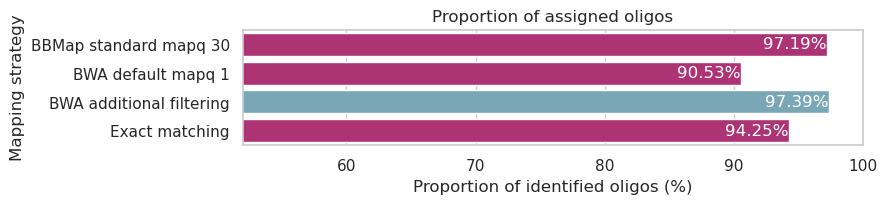

/tmp/ipykernel_514518/1358528525.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=condition, y='mapping_strategy', data=assignment_results_df, palette=color_list)


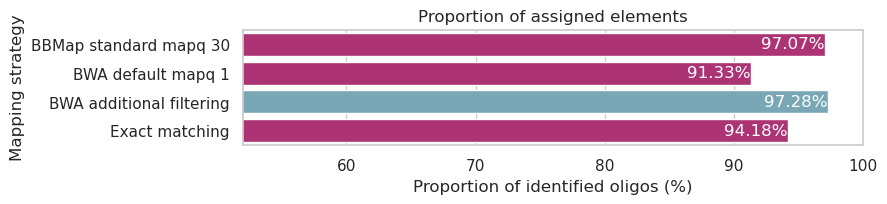

/tmp/ipykernel_514518/1358528525.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=condition, y='mapping_strategy', data=assignment_results_df, palette=color_list)


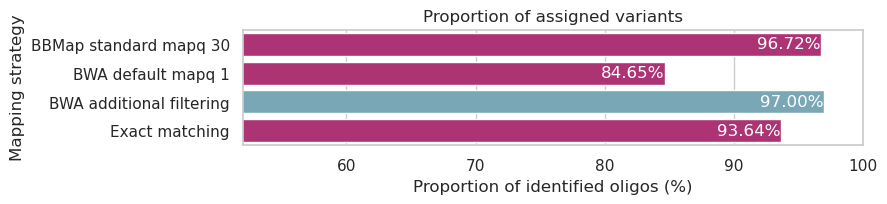

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
for condition, condition_name in [('proportion_of_assigned_oligos', 'Proportion of assigned oligos'), ('proportion_of_assigned_elements', 'Proportion of assigned elements'), ('proportion_of_assigned_variants', 'Proportion of assigned variants')]:
    plt.figure(figsize=(8, 1.5))
    # changing color based on the name of the mapping strategy (NOTE: might want to change to your mapping strategy names)
    color_list = ['#70ACC0' if 'BBMap' in x else '#C12075' for x in assignment_results_df.mapping_strategy]
    color_list = ['#70ACC0' if 'BWA add' in x else '#C12075' for x in assignment_results_df.mapping_strategy]
    ax = sns.barplot(x=condition, y='mapping_strategy', data=assignment_results_df, palette=color_list)
    ax.set_xlim(54, 98.5)
    ax.set_xlim(52, 100)
    # ax.set_xlim(79, 92)
    # annotate the bars with the rounded proportion_identified_oligos_rounded
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}%', (p.get_width() - 2.5, p.get_y() + p.get_height() / 2), ha='center', va='center', color='white')

    plt.xlabel('Proportion of identified oligos (%)')
    plt.ylabel('Mapping strategy')
    plt.title(f'{condition_name}')
    plt.show()

/tmp/ipykernel_514518/1485339648.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=condition, y='mapping_strategy', data=assignment_results_df, palette=color_list)


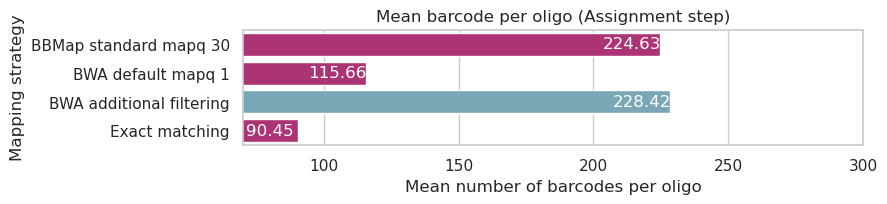

In [33]:
sns.set_theme(style="whitegrid")
for condition, condition_name in [('mean_barcode_per_oligo', 'Mean barcode per oligo (Assignment step)')]:
    plt.figure(figsize=(8, 1.5))
    color_list = ['#70ACC0' if 'BBMap' in x else '#C12075' for x in assignment_results_df.mapping_strategy]
    color_list = ['#70ACC0' if 'BWA addi' in x else '#C12075' for x in assignment_results_df.mapping_strategy]
    ax = sns.barplot(x=condition, y='mapping_strategy', data=assignment_results_df, palette=color_list)
    ax.set_xlim(79, 102)
    ax.set_xlim(79, 92)
    ax.set_xlim(60, 102)
    ax.set_xlim(70, 300)
    # annotate the bars with the rounded proportion_identified_oligos_rounded
    for p in ax.patches:
        ax.annotate(f'{round(p.get_width(),2)}', (p.get_width() - 10.5, p.get_y() + p.get_height() / 2), ha='center', va='center', color='white')

    plt.xlabel('Mean number of barcodes per oligo')
    plt.ylabel('Mapping strategy')
    plt.title(f'{condition_name}')
    plt.show()

In [ ]:
# TODO: Add the correlation here (checkup with Jon)

### Experiment
1. Read the MPRAsnakeflow counts with the replicate information
3. Count the oligos, elements and variants assigned
4. Plot the results

In [25]:
input_experiment_results = [
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_submission/80K/mprasnakeflow/results/experiments/defaultNGN2/assigned_counts/defaultAssignment/default/NGN2_allreps_merged.tsv.gz',
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/bwa_additional_filter_exact/results/experiments/NGN280kexperimentbwaMapQ1StrandSensitive/assigned_counts/assignmentFixDuplicates/default/NGN2_allreps_merged.tsv.gz',
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/bwa_additional_filter_exact/results/experiments/NGN280kExperimentBwaAdditionalFiltering/assigned_counts/assignmentFixDuplicates/default/NGN2_allreps_merged.tsv.gz',
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/bwa_additional_filter_exact/results/experiments/exactExperimentNoStrand/assigned_counts/assignmentFixDuplicates/default/NGN2_allreps_merged.tsv.gz',
 ]

input_experiment_results = [
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/results/experiments/ASDbbmapCount/assigned_counts/defaultAssignment/default/neurons_allreps_merged.tsv.gz',
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/results/experiments/ASDbwaCount/assigned_counts/ASDBWAAssignment/default/neurons_allreps_merged.tsv.gz',
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/results/experiments/ASDBWAadditionalFilteringCount/assigned_counts/defaultAssignment/default/neurons_allreps_merged.tsv.gz',
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/results/experiments/ASDexactCount/assigned_counts/defaultAssignment/default/neurons_allreps_merged.tsv.gz',
 ]

shorter_names_for_numbers = [
'BBMap standard mapq 30',
'BWA default mapq 1',
'BWA additional filtering',
'Exact matching'
]
input_experiment_results = [
    '/data/cephfs-2/unmirrored/groups/kircher/IGVF_data_submssion_TM/80K/mprasnakeflow/results/experiments/defaultWTC11Resequencing/assigned_counts/defaultAssignmentBBMap/default/WTC11_allreps_merged.tsv.gz',
    '/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/processing_mpralib/80k_WTC11_resequencing_normalized_counts.tsv.gz'
 ]

shorter_names_for_numbers = [
'undiffWTC11 BBMap standard mapq 30',
'undiffWTC11 BBMap normalized'
]

In [26]:
# helpful functions
import numpy as np

def filter_dna_rna_counts(count_table_df, rna_threshold=1, dna_threshold=1):
    """
    Filter the count table for RNA and DNA counts.
    """
    return count_table_df.loc[(count_table_df['rna_counts'] >= rna_threshold) & (count_table_df['dna_counts'] >= dna_threshold)].copy()


def filter_barcode_counts(count_table_df, threshold=10, bc_col='n_bc'):
    """
    Filter the count table for RNA and DNA counts.
    """
    return count_table_df.loc[(count_table_df[bc_col] >= threshold)].copy()


def combine_replicates(count_table_df, total_dna_counts, total_rna_counts, col_name=["condition", "name"]):
    # NOTE: condition was removed in the recent MPRAsnakemake release (0.4.5) (if you have problems using this function for your data ask Kilian Salomon)
    count_table_df = count_table_df.groupby(by=[col_name]).aggregate(
        {
            "replicate": "count",
            "dna_counts": ["sum", "mean"],
            "rna_counts": ["sum", "mean"],
            "dna_normalized": "mean",
            "rna_normalized": "mean",
            "log2FoldChange": "mean",
            "n_bc": ["sum", "mean"],
        }
    )

    count_table_df = count_table_df.reset_index()
    df_out = count_table_df.iloc[:, 0:1].copy()
    df_out.columns = [col_name]

    df_out["replicates"] = count_table_df.replicate["count"]

    scaling = 10**6

    df_out["dna_counts"] = count_table_df.dna_counts["sum"]
    df_out["rna_counts"] = count_table_df.rna_counts["sum"]


    df_out["dna_normalized"] = df_out["dna_counts"] / total_dna_counts * scaling
    df_out["rna_normalized"] = df_out["rna_counts"] / total_rna_counts * scaling

    df_out["old_ratio"] = df_out["rna_normalized"] / df_out["dna_normalized"]
    df_out["old_log2"] = np.log2(df_out.old_ratio)

    df_out["mean_dna_counts"] = count_table_df.dna_counts["mean"]
    df_out["mean_rna_counts"] = count_table_df.rna_counts["mean"]
    df_out["mean_dna_normalized"] = count_table_df.dna_normalized["mean"]
    df_out["mean_rna_normalized"] = count_table_df.rna_normalized["mean"]
    df_out["mean_log2FoldChange"] = count_table_df.log2FoldChange["mean"]

    df_out["n_bc_sum"] = count_table_df.n_bc["sum"]
    df_out["n_bc_mean"] = count_table_df.n_bc["mean"]

    return df_out.copy()


def filter_replicates(count_table_df, replicate_column='replicates', threshold=3):
    """
    Filter the count table for RNA and DNA counts.
    """
    return count_table_df.loc[count_table_df[replicate_column] >= threshold].copy()

In [27]:
# technical paper 2025:
# load lists:
count_numbers_variant_assigned = []
count_proportion_of_assigned_variants = []
count_assigned_oligos_filtered = []
count_proportion_of_assigned_oligos = []
count_numbers_assigned_elements = []
count_proportion_of_assigned_elements = []
count_mean_barcode_per_oligos = []
count_median_barcode_per_oligos = []
barcode_threhold = 10
n_tested_elements = get_number_of_expected_tested_elements(metadata_df[[col_name, col_sequence]], variant_map_df, label_name="", col_name=col_name, col_ALT='ALT', col_REF='REF')
n_tested_oligos = get_number_tested_oligos(metadata_df[[col_name, col_sequence]], col_name=col_name)
# n_tested_elements = get_number_of_expected_tested_elements(metadata_df[[col_name, col_sequence, 'sequence_name']], variant_map_df, label_name="", col_name='sequence_name', col_ALT='ALT', col_REF='REF')
# n_tested_oligos = get_number_tested_oligos(metadata_df[[col_name, col_sequence, 'sequence_name']], label_name="", col_name='sequence_name')
n_variants = get_number_of_variants(variant_map_df, col_ALT='ALT')
n_tested_variants = get_number_of_tested_variants(variant_map_df)


##### NOTE: different headers for MPRAsnakeflow used
# # reading the table which is used to map the correct names on the fly
# bwa_fine_design_path = "/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/ASD_design_picard_fine_fasta_name_association.tsv"
# bwa_fine_design_path = "/data/cephfs-2/unmirrored/groups/kircher/IGVF_data_submssion_TM/ASD_nadav/design/asd_picard_modified_design_name.tsv"

# bwa_fine_design_df = pd.read_csv(bwa_fine_design_path, sep="\t")
# bwa_fine_design_df.columns = ["oligo_name", "sequence", "bwa_name"]



for file in input_experiment_results:
    count_test_table = pd.read_csv(file, sep='\t')
    print(file)

    count_test_table = pd.read_csv(file, sep='\t')
    # NOTE: Core if your design file used for MPRAsnakeflow had different names as the metadata file
    # read it correctly:
    # column_names = ['replicate', 'bwa_name', 'dna_counts', 'rna_counts', 'dna_normalized',
    # 'rna_normalized', 'log2FoldChange', 'n_bc']
    # count_test_table.columns = column_names
    # count_test_table = count_test_table.merge(bwa_fine_design_df, on='bwa_name', how="inner").copy()

    # remove no_BC
    count_test_table_filtered = count_test_table.loc[~count_test_table['oligo_name'].str.contains('no_BC')].copy()

    # filter for RNA and DNA counts
    count_test_table_filtered = filter_dna_rna_counts(count_test_table_filtered).copy()
    count_test_table_filtered = filter_barcode_counts(count_test_table_filtered).copy()

    # combine replicates
    total_dna_counts = count_test_table_filtered[["dna_counts"]].sum().iloc[0]
    total_rna_counts = count_test_table_filtered[["rna_counts"]].sum().iloc[0]
    combined_replicates_df_raw = combine_replicates(count_test_table_filtered, total_dna_counts, total_rna_counts, col_name="oligo_name")
    combined_replicates_df = filter_replicates(combined_replicates_df_raw, replicate_column='replicates', threshold=3)

    # get number of oligos
    n_count_oligos = len(combined_replicates_df)
    proportion_count_oligos = round(n_count_oligos / metadata_df[col_name].nunique(), 2)


    # mean and median of barcode per oligo
    count_mean_bc, count_median_bc = get_mean_and_median_barcode_per_oligo(combined_replicates_df, barcode_count_column='n_bc_sum')
    # count_mean_bc, count_median_bc = get_mean_and_median_barcode_per_oligo(combined_replicates_df, barcode_count_column='n_obs_bc_mean')
    count_mean_barcode_per_oligos.append(count_mean_bc)
    count_median_barcode_per_oligos.append(count_median_bc)

    # get number and proportion of variants to be measured
    n_assigned_variants = get_number_of_variants_assigned(variant_map_df, combined_replicates_df, barcode_counts_column='n_bc_sum', header="oligo_name")
    proportion_assigned_variants = round(n_assigned_variants / n_variants * 100, 2)
    count_numbers_variant_assigned.append(n_assigned_variants)
    count_proportion_of_assigned_variants.append(proportion_assigned_variants)

    # number and proportion of assigned oligos
    count_filtered_assigned_oligo_number = get_number_of_assigned_oligos_filtered(combined_replicates_df, barcode_counts_column='n_bc_sum', threshold=barcode_threhold)
    count_filtered_assigned_oligo_proportion = get_proportion_of_assigned_oligos_filtered(combined_replicates_df, barcode_counts_column='n_bc_sum', threshold=barcode_threhold, max_number_oligos=metadata_df[col_name].nunique())
    count_assigned_oligos_filtered.append(count_filtered_assigned_oligo_number)
    count_proportion_of_assigned_oligos.append(count_filtered_assigned_oligo_proportion)

    # get number of assigned elements
    n_tested_elements_assigned = get_number_of_tested_elements_assigned(variant_map_df, combined_replicates_df, header='oligo_name', label_name='', col_ALT='ALT', col_REF='REF')
    proportion_of_tested_elements_assigned = round(n_tested_elements_assigned / n_tested_elements * 100, 2)
    count_numbers_assigned_elements.append(n_tested_elements_assigned)
    count_proportion_of_assigned_elements.append(proportion_of_tested_elements_assigned)


# make a dataframe out of the results
experiment_results_df = pd.DataFrame({
    'mapping_strategy': shorter_names_for_numbers,
    'mean_barcode_per_oligo': count_mean_barcode_per_oligos,
    'median_barcode_per_oligo': count_median_barcode_per_oligos,
    'assigned_oligos_filtered': count_assigned_oligos_filtered,
    'proportion_of_assigned_oligos': count_proportion_of_assigned_oligos,
    'numbers_assigned_elements': count_numbers_assigned_elements,
    'proportion_of_assigned_elements': count_proportion_of_assigned_elements,
    'numbers_variant_assigned': count_numbers_variant_assigned,
    'proportion_of_assigned_variants': count_proportion_of_assigned_variants,
})

/data/cephfs-2/unmirrored/groups/kircher/IGVF_data_submssion_TM/80K/mprasnakeflow/results/experiments/defaultWTC11Resequencing/assigned_counts/defaultAssignmentBBMap/default/WTC11_allreps_merged.tsv.gz
/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/processing_mpralib/80k_WTC11_resequencing_normalized_counts.tsv.gz


KeyError: 'oligo_name'

In [ ]:
experiment_results_df

,mapping_strategy,mean_barcode_per_oligo,median_barcode_per_oligo,assigned_oligos_filtered,proportion_of_assigned_oligos,numbers_assigned_elements,proportion_of_assigned_elements,numbers_variant_assigned,proportion_of_assigned_variants
0,undiffWTC11 BBMap standard mapq 30,159.839134,133.0,67516,84.17,29303,88.26,36071,76.68


#### Plot the experiment/count data

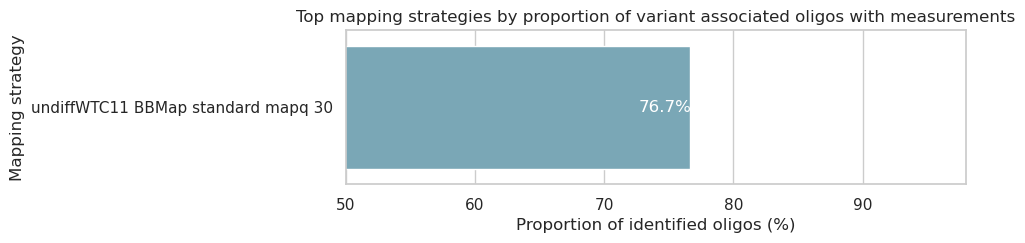

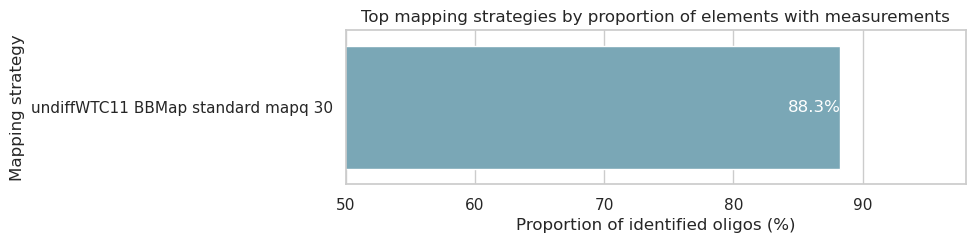

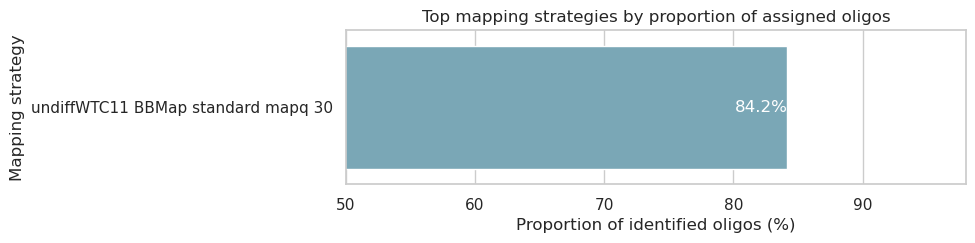

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
# mark the best performing mapping strategy with a specific color
experiment_results_df['color'] = experiment_results_df['mapping_strategy'].apply(lambda name: '#70ACC0' if 'BBMap' in name else '#C12075')
for condition, condition_name in [('proportion_of_assigned_variants', 'proportion of variant associated oligos with measurements'), ('proportion_of_assigned_elements', 'proportion of elements with measurements'), ('proportion_of_assigned_oligos', 'proportion of assigned oligos')]:
    plt.figure(figsize=(8, 2))
    ax = sns.barplot(x=condition, y='mapping_strategy', data=experiment_results_df, palette=experiment_results_df['color'].to_list(), hue='color', legend=False)
    # ax = sns.barplot(x=condition, y='mapping_strategy', data=experiment_results_df, hue='mapping_strategy', legend=False)
    # NOTE: you might want to adjust these numbers to have the resulting plot fit your data well
    ax.set_xlim(60, 92)
    ax.set_xlim(50, 96)
    ax.set_xlim(50, 98)
    # ax.set_xlim(79, 92)
    # annotate the bars with the rounded proportion_identified_oligos_rounded
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', (p.get_width() - 2, p.get_y() + p.get_height() / 2), ha='center', va='center', color='white')

    plt.xlabel('Proportion of identified oligos (%)')
    plt.ylabel('Mapping strategy')
    plt.title(f'Top mapping strategies by {condition_name}')
    plt.show()


/tmp/ipykernel_2393272/4261449569.py:9: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=condition, y='mapping_strategy', data=experiment_results_df, palette=experiment_results_df['color'].to_list(), hue='color', legend=False)


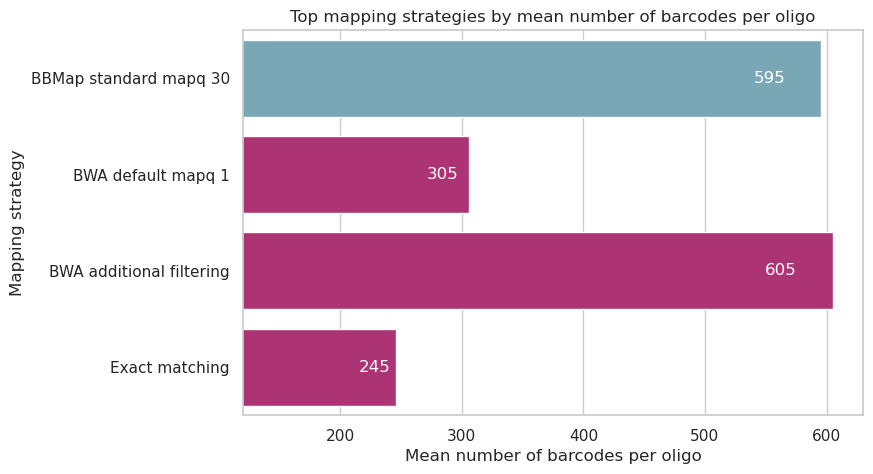

In [ ]:
x_lim_lower = 120
x_lim_upper = 630

# counts as x axis
for condition, condition_name in [('mean_barcode_per_oligo', 'mean number of barcodes per oligo')]:
    plt.figure(figsize=(8, 5))
    color_list = ['#70ACC0' if 'BBMap' in x else '#C12075' for x in experiment_results_df.mapping_strategy]
    ax = sns.barplot(x=condition, y='mapping_strategy', data=experiment_results_df, palette=experiment_results_df['color'].to_list(), hue='color', legend=False)
    ax.set_xlim(x_lim_lower, x_lim_upper)
    # annotate the bars with the rounded proportion_identified_oligos_rounded
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width() - p.get_width()*0.07, p.get_y() + p.get_height() / 2), ha='center', va='center', color='white')

    plt.xlabel('Mean number of barcodes per oligo')
    plt.ylabel('Mapping strategy')
    plt.title(f'Top mapping strategies by {condition_name}')
    plt.show()

/tmp/ipykernel_2393272/2038197516.py:4: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=condition, y='mapping_strategy', data=experiment_results_df, palette=experiment_results_df['color'].to_list(), hue='color', legend=False)


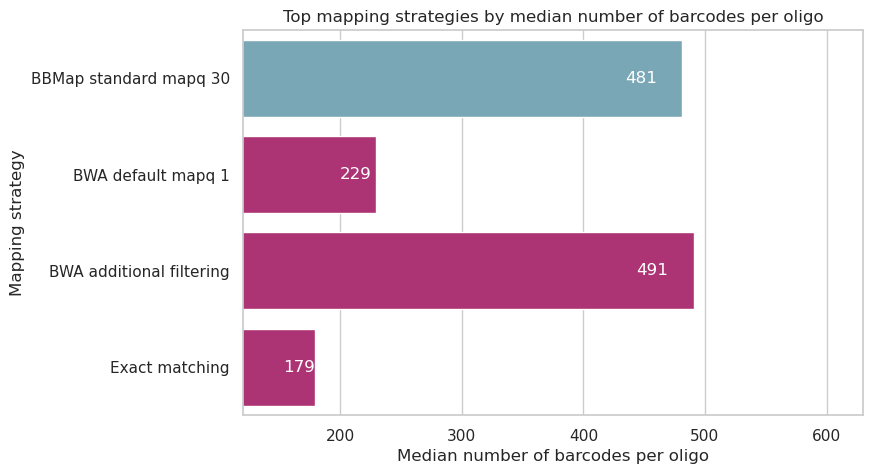

In [159]:
for condition, condition_name in [ ('median_barcode_per_oligo', 'median number of barcodes per oligo')]:
    plt.figure(figsize=(8, 5))
    color_list = ['#70ACC0' if 'BBMap' in x else '#C12075' for x in experiment_results_df.mapping_strategy]
    ax = sns.barplot(x=condition, y='mapping_strategy', data=experiment_results_df, palette=experiment_results_df['color'].to_list(), hue='color', legend=False)
    ax.set_xlim(x_lim_lower, x_lim_upper)
    # annotate the bars with the rounded proportion_identified_oligos_rounded
    for p in ax.patches:
        # NOTE: with the p.get_width() - <> you can move the position of the annotated number
        ax.annotate(f'{int(round(p.get_width(),0))}', (p.get_width() - p.get_width()*0.07, p.get_y() + p.get_height() / 2), ha='center', va='center', color='white')

    plt.xlabel('Median number of barcodes per oligo')
    plt.ylabel('Mapping strategy')
    plt.title(f'Top mapping strategies by {condition_name}')
    plt.show()

### Correlation:  mpralib

In [11]:
input_experiment_barcode_results = [
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/results/experiments/ASDbbmapCount/reporter_experiment.barcode.neurons.defaultAssignment.default.all.tsv.gz',
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/results/experiments/ASDbwaCount/reporter_experiment.barcode.neurons.ASDBWAAssignment.default.all.tsv.gz',
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/results/experiments/ASDBWAadditionalFilteringCount/reporter_experiment.barcode.neurons.defaultAssignment.default.all.tsv.gz',
    '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/ASD_MPRAsnakeflow/results/experiments/ASDexactCount/reporter_experiment.barcode.neurons.defaultAssignment.default.all.tsv.gz',
]

shorter_names_for_numbers = [
'BBMap standard mapq 30',
'BWA default mapq 1',
'BWA additional filtering',
'Exact matching'
]

In [3]:
testing = input_experiment_barcode_results[0]

In [1]:
# Loading the MPRAlib library
from mpralib.mpradata import MPRABarcodeData
# Loading other libraries
import pandas as pd
import numpy as np

In [4]:
# Load the data
mpra_barcode_data = MPRABarcodeData.from_file(testing)

# Getting counts, no filtering/sampling done, so raw counts
print("DNA counts")
display(pd.DataFrame(mpra_barcode_data.dna_counts[:,0:5], index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.var_names[0:5]))
print("RNA counts")
display(pd.DataFrame(mpra_barcode_data.rna_counts[:,0:5], index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.var_names[0:5]))

DNA counts


barcode,GTAATACACTTTTAA,TAAGTACCCGAGCGC,CCGCCGCTCCCCACC,AGTGAGGACAGTCTT,TCTACACTACGGAGA
1,2,8,32,13,6
2,6,5,48,12,7
3,9,9,38,12,10


RNA counts


barcode,GTAATACACTTTTAA,TAAGTACCCGAGCGC,CCGCCGCTCCCCACC,AGTGAGGACAGTCTT,TCTACACTACGGAGA
1,6,5,43,10,7
2,12,4,38,7,8
3,11,24,59,10,11


In [5]:
from mpralib.mpradata import Modality
print("Pairwise Pearson correlation activity")
print(pd.DataFrame(mpra_barcode_data.correlation(), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))
print("Pairwise Pearson correlation normalized DNA")
print(pd.DataFrame(mpra_barcode_data.correlation(count_type=Modality.DNA_NORMALIZED), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))
print("Pairwise Pearson correlation normalized RNA")
print(pd.DataFrame(mpra_barcode_data.correlation(count_type=Modality.RNA_NORMALIZED), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))


Pairwise Pearson correlation activity
       1      2      3
1  1.000  0.462  0.460
2  0.462  1.000  0.478
3  0.460  0.478  1.000
Pairwise Pearson correlation normalized DNA
       1      2      3
1  1.000  0.843  0.832
2  0.843  1.000  0.834
3  0.832  0.834  1.000
Pairwise Pearson correlation normalized RNA
       1      2      3
1  1.000  0.906  0.901
2  0.906  1.000  0.917
3  0.901  0.917  1.000


In [8]:
print("Pairwise Spearman correlation activity")
print(pd.DataFrame(mpra_barcode_data.correlation(method="spearman"), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))
print("Pairwise Spearman correlation normalized DNA")
print(pd.DataFrame(mpra_barcode_data.correlation(count_type=Modality.DNA_NORMALIZED, method="spearman"), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))
print("Pairwise Spearman correlation normalized RNA")
print(pd.DataFrame(mpra_barcode_data.correlation(count_type=Modality.RNA_NORMALIZED, method="spearman"), index=mpra_barcode_data.obs_names, columns=mpra_barcode_data.obs_names).round(3))


Pairwise Spearman correlation activity
       1      2      3
1  1.000  0.420  0.418
2  0.420  1.000  0.437
3  0.418  0.437  1.000
Pairwise Spearman correlation normalized DNA
       1      2      3
1  1.000  0.782  0.769
2  0.782  1.000  0.772
3  0.769  0.772  1.000
Pairwise Spearman correlation normalized RNA
       1      2      3
1  1.000  0.804  0.802
2  0.804  1.000  0.815
3  0.802  0.815  1.000


In [40]:
import numpy as np

def mean_correlation_of_mpra_oligo_matrix(matrix):
    """Get only the correlation values of the upper triangle of the matrix to compute the mean correlation"""
    return np.mean(matrix[np.triu_indices_from(matrix, k=1)]).round(3)

def min_correlation_of_mpra_oligo_matrix(matrix):
    """Get only the correlation values of the upper triangle of the matrix to compute the min correlation"""
    return np.min(matrix[np.triu_indices_from(matrix, k=1)]).round(3)


# compute average correlation for dna, rna and activity for the same threshold and plot that
activity_spearman_corr_min = []
activity_pearson_corr_min = []
activity_spearman_corr_mean = []
activity_pearson_corr_mean = []
rna_counts_normalized_spearman_corr_min = []
rna_counts_normalized_pearson_corr_min = []
rna_counts_normalized_spearman_corr_mean = []
rna_counts_normalized_pearson_corr_mean = []
dna_counts_normalized_spearman_corr_min = []
dna_counts_normalized_pearson_corr_min = []
dna_counts_normalized_spearman_corr_mean = []
dna_counts_normalized_pearson_corr_mean = []
threshold_dfs = []
for threshold in [1, 10, 50]:
    activity_spearman_corr_min = []
    activity_pearson_corr_min = []
    activity_spearman_corr_mean = []
    activity_pearson_corr_mean = []
    rna_counts_normalized_spearman_corr_min = []
    rna_counts_normalized_pearson_corr_min = []
    rna_counts_normalized_spearman_corr_mean = []
    rna_counts_normalized_pearson_corr_mean = []
    dna_counts_normalized_spearman_corr_min = []
    dna_counts_normalized_pearson_corr_min = []
    dna_counts_normalized_spearman_corr_mean = []
    dna_counts_normalized_pearson_corr_mean = []
    for mapping_strategy in input_experiment_barcode_results:
        # mapping_strategy = testing
        # read it
        mpra_barcode_data = MPRABarcodeData.from_file(mapping_strategy)

        # get the mpra oligo data
        mpra_oligo_data = mpra_barcode_data.oligo_data

        # set barcode threshold
        mpra_oligo_data.barcode_threshold = threshold
        # dna counts
        dna_counts_normalized_spearman_corr_min.append(min_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
        dna_counts_normalized_pearson_corr_min.append(min_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
        dna_counts_normalized_spearman_corr_mean.append(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
        dna_counts_normalized_pearson_corr_mean.append(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
        # rna counts
        rna_counts_normalized_spearman_corr_min.append(min_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
        rna_counts_normalized_pearson_corr_min.append(min_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
        rna_counts_normalized_spearman_corr_mean.append(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
        rna_counts_normalized_pearson_corr_mean.append(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
        # activity
        activity_spearman_corr_min.append(min_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
        activity_pearson_corr_min.append(min_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))
        activity_spearman_corr_mean.append(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation(method="spearman")))
        activity_pearson_corr_mean.append(mean_correlation_of_mpra_oligo_matrix(mpra_oligo_data.correlation()))


    # make a dataframe out of the results
    correlation_results_df = pd.DataFrame({
        'mapping_strategy': shorter_names_for_numbers,
        'activity_spearman_corr_min': activity_spearman_corr_min,
        'activity_pearson_corr_min': activity_pearson_corr_min,
        'activity_spearman_corr_mean': activity_spearman_corr_mean,
        'activity_pearson_corr_mean': activity_pearson_corr_mean,
        'rna_counts_normalized_spearman_corr_min': rna_counts_normalized_spearman_corr_min,
        'rna_counts_normalized_pearson_corr_min': rna_counts_normalized_pearson_corr_min,
        'rna_counts_normalized_spearman_corr_mean': rna_counts_normalized_spearman_corr_mean,
        'rna_counts_normalized_pearson_corr_mean': rna_counts_normalized_pearson_corr_mean,
        'dna_counts_normalized_spearman_corr_min': dna_counts_normalized_spearman_corr_min,
        'dna_counts_normalized_pearson_corr_min': dna_counts_normalized_pearson_corr_min,
        'dna_counts_normalized_spearman_corr_mean': dna_counts_normalized_spearman_corr_mean,
        'dna_counts_normalized_pearson_corr_mean': dna_counts_normalized_pearson_corr_mean,

    })
    threshold_dfs.append(correlation_results_df)


In [29]:
plotting_list = ["dna_counts_normalized_spearman_corr_min", "dna_counts_normalized_pearson_corr_min", "rna_counts_normalized_spearman_corr_min", "rna_counts_normalized_pearson_corr_min", "activity_spearman_corr_min", "activity_pearson_corr_min"]

/tmp/ipykernel_630409/1793061567.py:10: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=f"pearson_corr_min", y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)


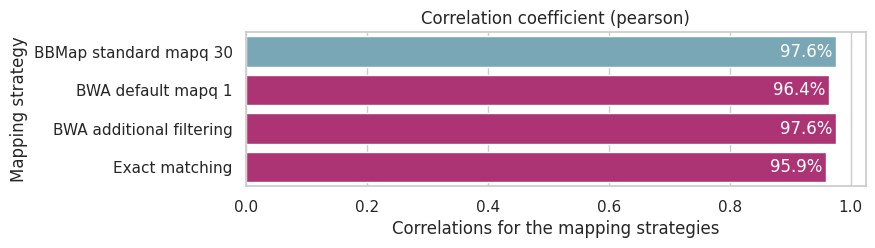

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

threshold_10_df = threshold_dfs[0] # 0: 1, 1: 10, 2: 50
# mark the best performing mapping strategy with a specific color
threshold_10_df['color'] = threshold_10_df['mapping_strategy'].apply(lambda name: '#70ACC0' if 'BBMap' in name else '#C12075')

plt.figure(figsize=(8, 2))
ax = sns.barplot(x=f"pearson_corr_min", y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)
# NOTE: you might want to adjust these numbers to have the resulting plot fit your data well
# ax.set_xlim(60, 92)
# ax.set_xlim(50, 96)
# ax.set_xlim(50, 98)
# ax.set_xlim(79, 92)
# annotate the bars with the rounded proportion_identified_oligos_rounded
for p in ax.patches:
    ax.annotate(f'{p.get_width()*100:.1f}%', (p.get_width()- 0.05, p.get_y() + p.get_height() / 2), ha='center', va='center', color='white')

plt.xlabel('Correlations for the mapping strategies')
plt.ylabel('Mapping strategy')
plt.title(f'Correlation coefficient (pearson)')
plt.show()


/tmp/ipykernel_630409/1668107106.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=plotting_column, y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)


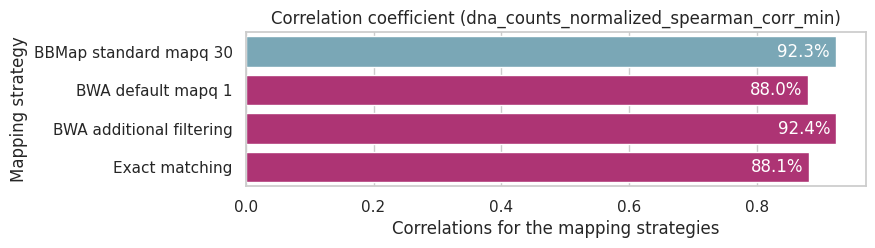

/tmp/ipykernel_630409/1668107106.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=plotting_column, y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)


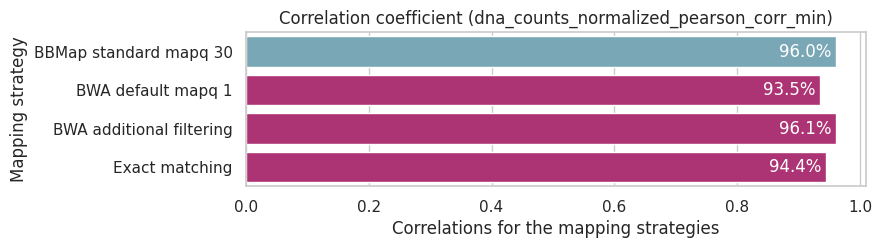

/tmp/ipykernel_630409/1668107106.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=plotting_column, y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)


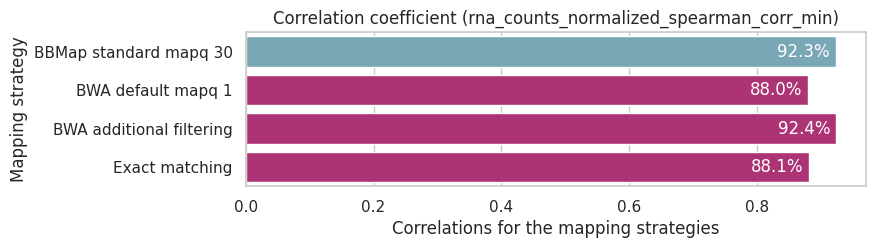

/tmp/ipykernel_630409/1668107106.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=plotting_column, y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)


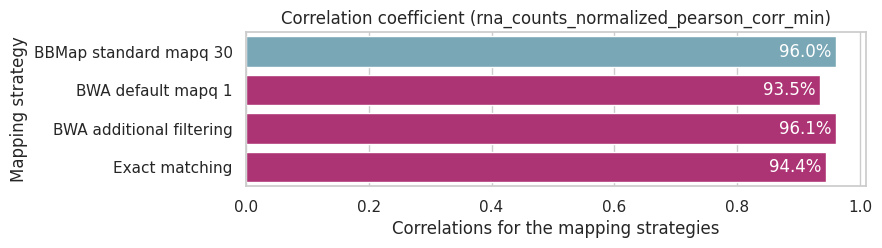

/tmp/ipykernel_630409/1668107106.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=plotting_column, y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)


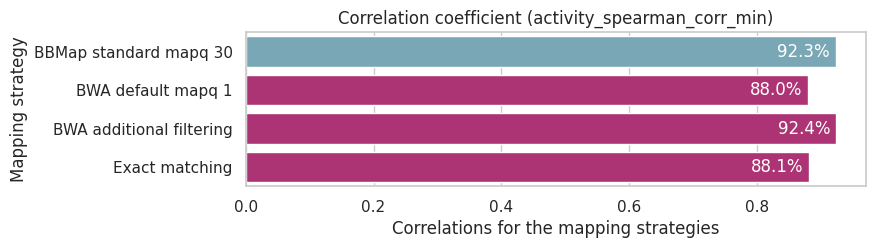

/tmp/ipykernel_630409/1668107106.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=plotting_column, y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)


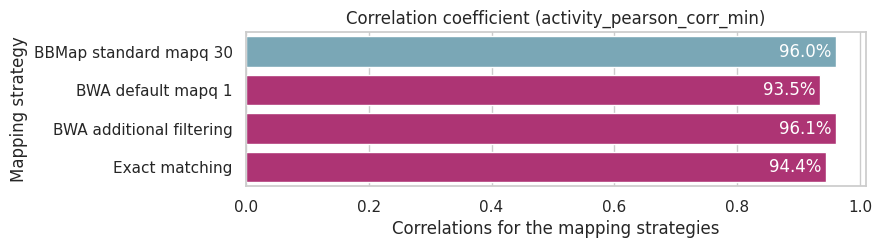

In [42]:
threshold_level = 1
threshold_10_df = threshold_dfs[0] # # 0: 1, 1: 10, 2: 50

for plotting_column in plotting_list:
    sns.set_theme(style="whitegrid")

    # mark the best performing mapping strategy with a specific color
    threshold_10_df['color'] = threshold_10_df['mapping_strategy'].apply(lambda name: '#70ACC0' if 'BBMap' in name else '#C12075')

    plt.figure(figsize=(8, 2))
    ax = sns.barplot(x=plotting_column, y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)
    # NOTE: you might want to adjust these numbers to have the resulting plot fit your data well
    # ax.set_xlim(60, 92)
    # ax.set_xlim(50, 96)
    # ax.set_xlim(50, 98)
    # ax.set_xlim(79, 92)
    # annotate the bars with the rounded proportion_identified_oligos_rounded
    for p in ax.patches:
        ax.annotate(f'{p.get_width()*100:.1f}%', (p.get_width()- 0.05, p.get_y() + p.get_height() / 2), ha='center', va='center', color='white')

    plt.xlabel('Correlations for the mapping strategies')
    plt.ylabel('Mapping strategy')
    plt.title(f'Correlation coefficient ({plotting_column})')
    plt.savefig(f"/home/kisa/coding/technical_paper2025/results/correlation_plots/mapping_strategy_correlation_{threshold_level}_{plotting_column}.png", bbox_inches="tight")
    plt.show()

/tmp/ipykernel_630409/3446755762.py:10: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(x=f"spearman_corr_min", y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)


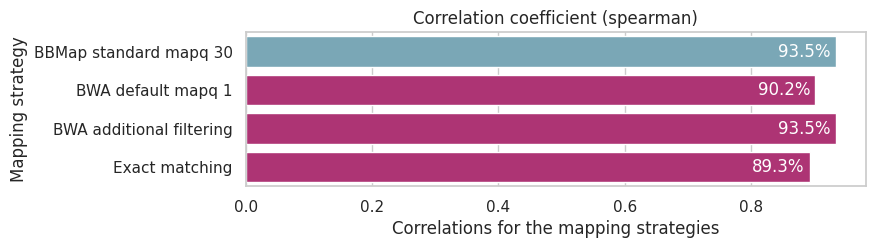

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

threshold_10_df = threshold_dfs[0]
# mark the best performing mapping strategy with a specific color
threshold_10_df['color'] = threshold_10_df['mapping_strategy'].apply(lambda name: '#70ACC0' if 'BBMap' in name else '#C12075')

plt.figure(figsize=(8, 2))
ax = sns.barplot(x=f"spearman_corr_min", y='mapping_strategy', data=threshold_10_df, palette=threshold_10_df['color'].to_list(), hue='color', legend=False)
# NOTE: you might want to adjust these numbers to have the resulting plot fit your data well
# ax.set_xlim(60, 92)
# ax.set_xlim(50, 96)
# ax.set_xlim(50, 98)
# ax.set_xlim(79, 92)
# annotate the bars with the rounded proportion_identified_oligos_rounded
for p in ax.patches:
    ax.annotate(f'{p.get_width()*100:.1f}%', (p.get_width()- 0.05, p.get_y() + p.get_height() / 2), ha='center', va='center', color='white')

plt.xlabel('Correlations for the mapping strategies')
plt.ylabel('Mapping strategy')
plt.title(f'Correlation coefficient (spearman)')
plt.show()